In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arnab0507/audio-55min/Renamed_audio_ori_hat_55min/Flush31-0.wav
/kaggle/input/datasets/arnab0507/audio-55min/Renamed_audio_ori_hat_55min/Flush_167__18_17 (1)-0.wav
/kaggle/input/datasets/arnab0507/audio-55min/Renamed_audio_ori_hat_55min/Door263_476 (168)-1.wav
/kaggle/input/datasets/arnab0507/audio-55min/Renamed_audio_ori_hat_55min/Flush_167_33_3-0.wav
/kaggle/input/datasets/arnab0507/audio-55min/Renamed_audio_ori_hat_55min/Door167_87-1.wav
/kaggle/input/datasets/arnab0507/audio-55min/Renamed_audio_ori_hat_55min/Door263_476 (139)-1.wav
/kaggle/input/datasets/arnab0507/audio-55min/Renamed_audio_ori_hat_55min/Door206-1.wav
/kaggle/input/datasets/arnab0507/audio-55min/Renamed_audio_ori_hat_55min/Door478_611 (29)-1.wav
/kaggle/input/datasets/arnab0507/audio-55min/Renamed_audio_ori_hat_55min/Door263_476 (62)-1.wav
/kaggle/input/datasets/arnab0507/audio-55min/Renamed_audio_ori_hat_55min/Flush40-0.wav
/kaggle/input/datasets/arnab0507/audio-55min/Renamed_audio_ori_hat_55

In [2]:
# =========================
# IMPORTS
# =========================
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import librosa
from glob import glob
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# =========================
# PARAMETERS
# =========================
INPUT_LENGTH = 30225
HOP_LENGTH = 10225
NO_CLASSES = 7
SAMPLING_RATE = 20000
EPOCHS = 50

dataset_path = "/kaggle/input/datasets/arnab0507/audio-55min"

# =========================
# LOAD AUDIO FILES
# =========================
audio_files = glob(os.path.join(dataset_path, '**', '*.wav'), recursive=True)
print("Total audio files:", len(audio_files))

X = []
Y = []

hamming_window = np.hamming(INPUT_LENGTH)

for audio_file in tqdm(audio_files):

    audio,_ = librosa.load(audio_file, sr=SAMPLING_RATE)

    for index in range(0, audio.shape[-1], INPUT_LENGTH-HOP_LENGTH):

        if index + INPUT_LENGTH > audio.shape[-1]:
            break

        x = audio[index:index+INPUT_LENGTH]
        x = x*hamming_window

        x = np.expand_dims(x,axis=0)

        y = int(os.path.basename(os.path.splitext(audio_file)[0]).split('-')[-1])
        y = np.expand_dims(y,axis=0)

        X.append(x)
        Y.append(y)

X = np.concatenate(X,axis=0)
Y = np.concatenate(Y,axis=0)

print("Total samples:",X.shape)

# =========================
# NORMALIZATION
# =========================
scaler = StandardScaler()
scaler.fit(X)

with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)

X = scaler.transform(X)

X = np.expand_dims(X,axis=1)
X = np.expand_dims(X,axis=3)

X,Y = shuffle(X,Y)

# =========================
# TRAIN TEST SPLIT
# =========================
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.1,random_state=42)
x_train,x_val,y_train,y_val = train_test_split(x_train,y_train,test_size=0.1,random_state=42)

print("Train:",x_train.shape)
print("Test:",x_test.shape)

# =========================
# SYNCNET MODEL
# =========================
input_layer = Input(shape=(1,30225,1))

x = Conv2D(32,(1,9),strides=(1,2),padding="same")(input_layer)
x = BatchNormalization()(x)
x = Activation("relu")(x)

x = Conv2D(64,(1,5),strides=(1,2),padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)

x = MaxPooling2D((1,4))(x)

x = DepthwiseConv2D((1,3),padding="same")(x)
x = SeparableConv2D(128,(1,1))(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)

x = MaxPooling2D((1,2))(x)

x = DepthwiseConv2D((1,3),padding="same")(x)
x = SeparableConv2D(256,(1,1))(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)

x = MaxPooling2D((1,2))(x)

x = Conv2D(256,(1,7),padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)

x = Conv2D(512,(1,5),padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

output = Dense(7,activation="softmax")(x)

model = Model(input_layer,output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =========================
# PCA BEFORE TRAINING
# =========================
feature_model = Model(inputs=model.inputs,outputs=model.layers[-3].output)

features = feature_model.predict(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

kmeans = KMeans(n_clusters=7)
labels = kmeans.fit_predict(pca_result)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0],pca_result[:,1],c=labels)
plt.title("PCA Before Training")
plt.savefig("pca_before_training_syncnet.png")
plt.clf()

# =========================
# TSNE BEFORE TRAINING
# =========================
tsne = TSNE(n_components=2)

tsne_result = tsne.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(tsne_result[:,0],tsne_result[:,1],c=labels)
plt.title("TSNE Before Training")
plt.savefig("tsne_before_training_syncnet.png")
plt.clf()

# =========================
# TRAINING
# =========================
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=EPOCHS,
    validation_data=(x_test,y_test),
    callbacks=[
        ReduceLROnPlateau(monitor="val_loss",factor=0.3,patience=5),
        ModelCheckpoint("SyncNet.keras",monitor="val_accuracy",save_best_only=True)
    ]
)

# =========================
# ACCURACY PLOT
# =========================
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy vs Epoch")
plt.legend(["train","val"])
plt.savefig("syncnet_accuracy.png")
plt.clf()

# =========================
# LOSS PLOT
# =========================
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss vs Epoch")
plt.legend(["train","val"])
plt.savefig("syncnet_loss.png")
plt.clf()

# =========================
# CONFUSION MATRIX
# =========================
y_pred = np.argmax(model.predict(x_test),axis=1)

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.title("Confusion Matrix SyncNet")
plt.savefig("syncnet_cm.png")
plt.clf()

# =========================
# PCA AFTER TRAINING
# =========================
features = feature_model.predict(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

plt.scatter(pca_result[:,0],pca_result[:,1],c=Y)
plt.title("PCA After Training")
plt.savefig("pca_after_training_syncnet.png")
plt.clf()

# =========================
# TSNE AFTER TRAINING
# =========================
tsne = TSNE(n_components=2)

tsne_result = tsne.fit_transform(features)

plt.scatter(tsne_result[:,0],tsne_result[:,1],c=Y)
plt.title("TSNE After Training")
plt.savefig("tsne_after_training_syncnet.png")
plt.clf()

# =========================
# EVALUATION
# =========================
print("Train Accuracy:",model.evaluate(x_train,y_train))
print("Test Accuracy:",model.evaluate(x_test,y_test))

# =========================
# TFLITE CONVERSION
# =========================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("SyncNet.tflite","wb") as f:
    f.write(tflite_model)

# =========================
# MODEL SIZE
# =========================
def convert_bytes(bytes):
    return bytes/(1024*1024)

size1 = convert_bytes(os.path.getsize("SyncNet.keras"))
size2 = convert_bytes(os.path.getsize("SyncNet.tflite"))

print("SyncNet.keras size:",size1,"MB")
print("SyncNet.tflite size:",size2,"MB")

2026-05-06 08:50:19.850722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778057420.053525      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778057420.107795      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778057420.546110      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778057420.546143      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778057420.546146      23 computation_placer.cc:177] computation placer alr

Total audio files: 788


100%|██████████| 788/788 [00:34<00:00, 22.78it/s]


Total samples: (21387, 30225)
Train: (17323, 1, 30225, 1)
Test: (2139, 1, 30225, 1)


I0000 00:00:1778057492.767996      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


...

Saved artifact at '/tmp/tmpf_z0xxs7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1, 30225, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  132053172070992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053167164112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053167162192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053167165840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053167162576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053167161616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053167165456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053167165648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053167164880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053167166800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13205316716660

W0000 00:00:1778060049.025750      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778060049.025781      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1778060049.047139      23 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [3]:

# TFLITE ACCURACY


interpreter = tf.lite.Interpreter(model_content=tflite_model)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()

output_details = interpreter.get_output_details()

correct = 0

for x,y in zip(x_test,y_test):

    x = np.expand_dims(x,axis=0).astype(np.float32)

    interpreter.set_tensor(input_details[0]['index'],x)

    interpreter.invoke()

    pred = np.argmax(interpreter.get_tensor(output_details[0]['index']))

    if pred == y:
        correct += 1

print("TFLite Accuracy:",100*correct/len(x_test))

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


TFLite Accuracy: 96.82094436652642


In [4]:

# INT8 QUANTIZATION CELL


import tensorflow as tf
import numpy as np

# Representative dataset (required for INT8)
def representative_dataset():
    for i in range(100):
        sample = x_train[i]
        sample = np.expand_dims(sample, axis=0).astype(np.float32)
        yield [sample]

# Load trained model
model = tf.keras.models.load_model("SyncNet.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Provide representative dataset
converter.representative_dataset = representative_dataset

# Force full INT8 quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert model
tflite_quant_model = converter.convert()

# Save INT8 model
with open("SyncNet_INT8.tflite", "wb") as f:
    f.write(tflite_quant_model)

print("INT8 model saved as SyncNet_INT8.tflite")

INFO:tensorflow:Assets written to: /tmp/tmp4pix43zr/assets


INFO:tensorflow:Assets written to: /tmp/tmp4pix43zr/assets


Saved artifact at '/tmp/tmp4pix43zr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1, 30225, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  132053177108816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053177110928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053177107664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053177107088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053177108240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053177108048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053177110736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053177109200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053177108624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053177108432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132053177109584

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1778060088.993417      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778060088.993445      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


INT8 model saved as SyncNet_INT8.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [5]:
interpreter = tf.lite.Interpreter(model_path="SyncNet_INT8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero_point = input_details[0]['quantization']

correct = 0

for x, y in zip(x_test, y_test):

    x = np.expand_dims(x, axis=0)

    # Quantize input
    x = x / input_scale + input_zero_point
    x = x.astype(np.int8)

    interpreter.set_tensor(input_details[0]['index'], x)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])

    prediction = np.argmax(output)

    if prediction == y:
        correct += 1

print("INT8 Accuracy:", 100 * correct / len(x_test))

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


INT8 Accuracy: 73.39878447872837


In [6]:
!pip install librosa seaborn tqdm --quiet

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import pickle

from glob import glob
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

In [8]:
INPUT_LENGTH = 30225
HOP_LENGTH = 10225
NO_CLASSES = 7
SAMPLING_RATE = 20000
EPOCHS = 50

In [9]:
dataset_path = "/kaggle/input/datasets/arnab0507/audio-55min"

audio_files = glob(os.path.join(dataset_path,"**/*.wav"),recursive=True)

print("Total audio files:",len(audio_files))

Total audio files: 788


In [10]:
X=[]
Y=[]

window=np.hamming(INPUT_LENGTH)

for file in tqdm(audio_files):

    audio,_=librosa.load(file,sr=SAMPLING_RATE)

    for index in range(0,len(audio),INPUT_LENGTH-HOP_LENGTH):

        if index+INPUT_LENGTH>len(audio):
            break

        x=audio[index:index+INPUT_LENGTH]
        x=x*window
        x=np.expand_dims(x,axis=0)

        label=int(os.path.basename(file).split('-')[-1].split('.')[0])

        X.append(x)
        Y.append(label)

X=np.array(X)
Y=np.array(Y)

100%|██████████| 788/788 [00:06<00:00, 125.30it/s]


100%|██████████| 788/788 [00:05<00:00, 152.44it/s]


Segments: (21387, 30225)
Train: (19248, 1, 30225, 1)
Test: (2139, 1, 30225, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 1, 15109, 8)    │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1, 15109, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 1, 15109, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 1, 7553, 64)    │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1, 7553, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 1, 7553, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 151, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 64, 151, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 151, 64)    │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 151, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64, 151, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 151, 64)    │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 151, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 151, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 75, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 75, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 75, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 32, 75, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 37, 128)    │             

 Total params: 4,707,247 (17.96 MB)

 Trainable params: 4,703,263 (17.94 MB)

 Non-trainable params: 3,984 (15.56 KB)

Epoch 1/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 59s 140ms/step - accuracy: 0.3377 - loss: 3.1103 - val_accuracy: 0.3787 - val_loss: 1.6767
Epoch 2/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 27s 90ms/step - accuracy: 0.7522 - loss: 0.6523 - val_accuracy: 0.6512 - val_loss: 1.2754
Epoch 3/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 27s 90ms/step - accuracy: 0.8285 - loss: 0.4698 - val_accuracy: 0.7186 - val_loss: 1.0570
Epoch 4/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 27s 90ms/step - accuracy: 0.8631 - loss: 0.3845 - val_accuracy: 0.8672 - val_loss: 0.3800
Epoch 5/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 27s 90ms/step - accuracy: 0.8858 - loss: 0.3099 - val_accuracy: 0.7803 - val_loss: 0.6271
Epoch 6/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 27s 90ms/step - accuracy: 0.9066 - loss: 0.2653 - val_accuracy: 0.8691 - val_loss: 0.3692
Epoch 7/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 27s 90ms/step - accuracy: 0.9147 - loss: 0.2457 - val_accuracy: 0.9191 - val_loss: 0.2034
Epoch 8/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 27s 91ms/step - accuracy: 0.9230 - loss: 0.2167 -

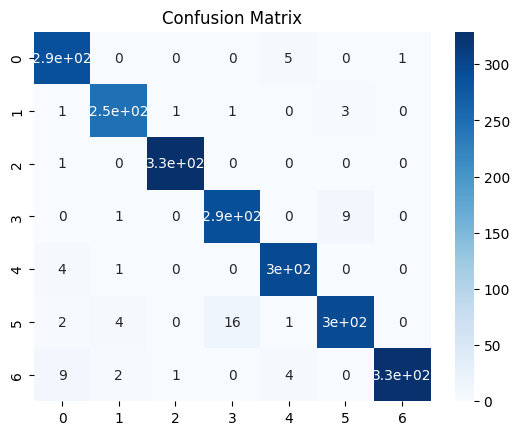

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       294
           1       0.97      0.98      0.97       253
           2       0.99      1.00      1.00       330
           3       0.94      0.97      0.96       300
           4       0.97      0.98      0.98       301
           5       0.96      0.93      0.94       318
           6       1.00      0.95      0.97       343

    accuracy                           0.97      2139
   macro avg       0.97      0.97      0.97      2139
weighted avg       0.97      0.97      0.97      2139

669/669 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step


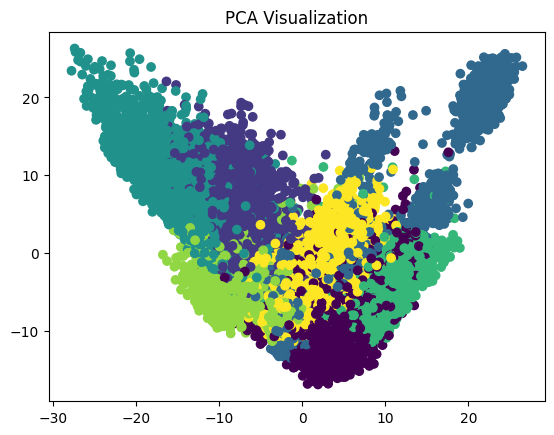

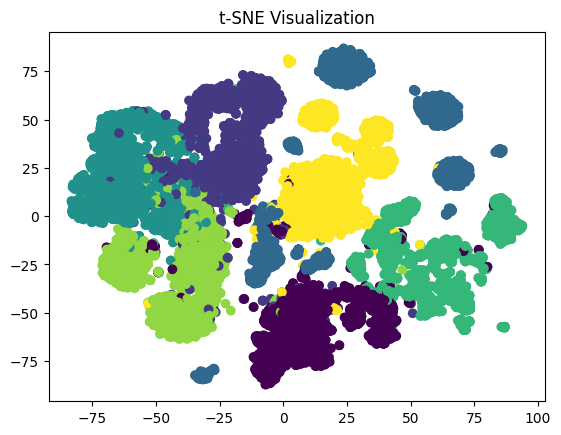

INFO:tensorflow:Assets written to: /tmp/tmpmw17i0k0/assets


INFO:tensorflow:Assets written to: /tmp/tmpmw17i0k0/assets


Saved artifact at '/tmp/tmpmw17i0k0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1, 30225, 1), dtype=tf.float32, name='keras_tensor_79')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  132047769923856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769924240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769925008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769923088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769922704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769923280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769925584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769924624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769925200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769923472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13204776992

W0000 00:00:1778061936.586819      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778061936.586848      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite model saved
TFLite Accuracy: 96.86769518466573


In [11]:
# ============================================================
# ACDNet Reproduction 


!pip install librosa soundfile seaborn scikit-learn tqdm --quiet

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import pickle

from tqdm import tqdm
from glob import glob

import librosa

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.utils import shuffle

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization
from tensorflow.keras.layers import Activation, MaxPooling2D
from tensorflow.keras.layers import Permute, Dropout
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Flatten, Dense



# ============================================================
# FEATURE EXTRACTION
# ============================================================

X = []
Y = []

window = np.hamming(INPUT_LENGTH)

for file in tqdm(audio_files):

    audio, _ = librosa.load(file, sr=SAMPLING_RATE)

    for index in range(0, audio.shape[0], INPUT_LENGTH - HOP_LENGTH):

        if index + INPUT_LENGTH > audio.shape[0]:
            break

        x = audio[index:index+INPUT_LENGTH]
        x = x * window
        x = np.expand_dims(x, axis=0)

        label = int(os.path.basename(file).split('-')[-1].split('.')[0])
        label = np.expand_dims(label, axis=0)

        X.append(x)
        Y.append(label)

X = np.concatenate(X, axis=0)
Y = np.concatenate(Y, axis=0)

print("Segments:", X.shape)

# ============================================================
# NORMALIZATION
# ============================================================

scaler = StandardScaler()

X = scaler.fit_transform(X)

with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)

# ============================================================
# CNN INPUT SHAPE
# ============================================================

X = np.expand_dims(X, axis=1)
X = np.expand_dims(X, axis=3)

X, Y = shuffle(X,Y)

x_train,x_test,y_train,y_test = train_test_split(
    X,Y,test_size=0.1,random_state=42
)

print("Train:",x_train.shape)
print("Test:",x_test.shape)

# ============================================================
# ACDNet MODEL (Correct Architecture)
# ============================================================

model = Sequential()

# -------------------------
# SFEB
# -------------------------

model.add(Conv2D(8,(1,9),strides=(1,2),padding='valid',
input_shape=(1,30225,1),use_bias=False))

model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(64,(1,5),strides=(1,2),padding='valid',use_bias=False))

model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D((1,50),(1,50)))

model.add(Permute((3,2,1)))

# -------------------------
# TFEB
# -------------------------
# TFEB Block

model.add(Conv2D(64,(3,3),padding='same',use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(64,(3,3),padding='same',use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),padding='same',use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(128,(3,3),padding='same',use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256,(3,3),padding='same',use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(256,(3,3),padding='same',use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(512,(3,3),padding='same',use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(512,(3,3),padding='same',use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

# -------------------------
# CLASSIFIER
# -------------------------

model.add(Dropout(0.3))

model.add(AveragePooling2D((2,4)))

model.add(Flatten())

model.add(Dense(7,activation='softmax'))

# ============================================================
# COMPILE
# ============================================================

model.compile(
loss=tf.keras.losses.SparseCategoricalCrossentropy(),
optimizer=tf.keras.optimizers.SGD(
learning_rate=0.1,
momentum=0.9,
nesterov=True),
metrics=['accuracy']
)

model.summary()

# ============================================================
# TRAIN
# ============================================================

history = model.fit(
x_train,
y_train,
epochs=EPOCHS,
batch_size=64,
validation_data=(x_test,y_test)
)

from sklearn.metrics import accuracy_score

# prediction
y_pred = np.argmax(model.predict(x_test), axis=1)

# calculate accuracy
acc = accuracy_score(y_test, y_pred)


print("\nModel Performance")
print("--------------------------")
print(f"Accuracy        : {acc*100:.2f}%")
print(f"Train Samples   : {len(x_train)}")
print(f"Test Samples    : {len(x_test)}")
print(f"Model Params    : {model.count_params():,}")


# ============================================================
# CONFUSION MATRIX
# ============================================================

y_pred = np.argmax(model.predict(x_test),axis=1)

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

print(classification_report(y_test,y_pred))

############################################################
# FEATURE EXTRACTION FOR PCA / TSNE
############################################################

feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.layers[-4].output
)

features = feature_model.predict(X)

features = features.reshape(features.shape[0], -1)

############################################################
# PCA
############################################################

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

plt.scatter(pca_result[:,0], pca_result[:,1], c=Y)
plt.title("PCA Visualization")
plt.show()

############################################################
# TSNE
############################################################

tsne = TSNE(n_components=2)
tsne_result = tsne.fit_transform(features)

plt.scatter(tsne_result[:,0], tsne_result[:,1], c=Y)
plt.title("t-SNE Visualization")
plt.show()

# ============================================================
# TFLITE CONVERSION
# ============================================================

converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("ACDNet.tflite","wb") as f:
    f.write(tflite_model)

print("TFLite model saved")

# ============================================================
# TFLITE ACCURACY
# ============================================================

interpreter = tf.lite.Interpreter(model_content=tflite_model)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()

output_details = interpreter.get_output_details()

correct = 0

for x,y in zip(x_test,y_test):

    x = np.expand_dims(x,axis=0).astype(np.float32)

    interpreter.set_tensor(input_details[0]['index'],x)

    interpreter.invoke()

    pred = np.argmax(interpreter.get_tensor(output_details[0]['index']))

    if pred == y:
        correct += 1

print("TFLite Accuracy:",100*correct/len(x_test))

In [12]:
# ============================================================
# INT8 QUANTIZATION (POST TRAINING)
# ============================================================

def representative_data_gen():
    
    for i in range(100):
        data = x_train[i]
        data = np.expand_dims(data, axis=0).astype(np.float32)
        yield [data]


converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable INT8 Quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Representative dataset for calibration
converter.representative_dataset = representative_data_gen

# Set INT8 inference
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8


tflite_int8_model = converter.convert()


with open("ACDNet_INT8.tflite", "wb") as f:
    f.write(tflite_int8_model)

print("INT8 Quantized TFLite Model Saved")

INFO:tensorflow:Assets written to: /tmp/tmp3tguiwxh/assets


INFO:tensorflow:Assets written to: /tmp/tmp3tguiwxh/assets


Saved artifact at '/tmp/tmp3tguiwxh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1, 30225, 1), dtype=tf.float32, name='keras_tensor_79')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  132047769923856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769924240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769925008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769923088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769922704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769923280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769925584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769924624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769925200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132047769923472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13204776992

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1778062043.857389      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778062043.857414      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


INT8 Quantized TFLite Model Saved


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [13]:
# ============================================================
# INT8 TFLITE ACCURACY
# ============================================================

interpreter = tf.lite.Interpreter(model_path="ACDNet_INT8.tflite")

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

correct = 0

for x, y in zip(x_test, y_test):

    x = np.expand_dims(x, axis=0)

    # scale to INT8
    scale, zero_point = input_details[0]['quantization']
    x = x / scale + zero_point
    x = x.astype(np.int8)

    interpreter.set_tensor(input_details[0]['index'], x)

    interpreter.invoke()

    pred = np.argmax(interpreter.get_tensor(output_details[0]['index']))

    if pred == y:
        correct += 1

print("INT8 TFLite Accuracy:", 100 * correct / len(x_test))

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


INT8 TFLite Accuracy: 78.49462365591398
